# 03 — Exploratory Data Analysis (EDA)

This notebook supports **Session 3 (EDA)** of the Streaming Video on Demand BI project.

You will:
- Load the cleaned datasets (Movies + TV Shows)
- Perform quick dataset profiling (shape, columns, missingness, duplicates)
- Use descriptive statistics to summarize distributions
- Build exploratory charts using **matplotlib** (bar charts, histograms, line charts)
- Complete an **in-session exercise**: create at least **3 plots** + 1–2 sentence interpretation each

**Datasets**
- `MoviesOnStreamingPlatforms_Cleaned.csv`
- `TVShowsOnStreamingPlatforms_Cleaned.csv`


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

DATA_DIR = Path("/Users/joanna/Desktop/Open Avenues/Data")  # adjust if needed

MOVIES_PATH = DATA_DIR / "MoviesOnStreamingPlatforms_Cleaned.csv"
TV_PATH     = DATA_DIR / "TVShowsOnStreamingPlatforms_Cleaned.csv"

## 1. Load the cleaned datasets

In [2]:
movies = pd.read_csv(MOVIES_PATH)
tv     = pd.read_csv(TV_PATH)

print("Movies shape:", movies.shape)
print("TV shape:    ", tv.shape)

movies.head()

Movies shape: (9515, 19)
TV shape:     (5368, 19)


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key
0,1,The Irishman,2019,18+,98/100,1,0,0,0,movie,"Biography, Crime, Drama",United States,"English, Italian, Latin, Spanish, German",7.8,tt1302006,98.0,18.0,0,the irishman
1,2,Dangal,2016,7+,97/100,1,0,0,0,movie,"Action, Biography, Drama","India, United States","Hindi, English",8.3,tt5074352,97.0,7.0,0,dangal
2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,movie,"Documentary, Biography",United Kingdom,English,8.9,tt11989890,95.0,7.0,0,david attenborough: a life on our planet
3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,movie,"Drama, Musical, Sport","India, United States","Hindi, English",8.1,tt0169102,94.0,7.0,0,lagaan: once upon a time in india
4,5,Roma,2018,18+,94/100,1,0,0,0,movie,Drama,"Mexico, United States","Spanish, Mixtec, English, Japanese, German, Fr...",7.6,tt6155172,94.0,18.0,0,roma


## 2. Quick dataset overview

In [3]:
def quick_overview(df: pd.DataFrame, name: str):
    print(f"=== {name} ===")
    display(df.head(3))
    print("\nColumns & dtypes:")
    display(pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str)}))
    print("\nMissing values (top 20):")
    missing = df.isna().sum().sort_values(ascending=False)
    display(missing.head(20).to_frame("missing_count"))
    print("\nInfo:")
    df.info()

quick_overview(movies, "Movies")

=== Movies ===


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key
0,1,The Irishman,2019,18+,98/100,1,0,0,0,movie,"Biography, Crime, Drama",United States,"English, Italian, Latin, Spanish, German",7.8,tt1302006,98.0,18.0,0,the irishman
1,2,Dangal,2016,7+,97/100,1,0,0,0,movie,"Action, Biography, Drama","India, United States","Hindi, English",8.3,tt5074352,97.0,7.0,0,dangal
2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,movie,"Documentary, Biography",United Kingdom,English,8.9,tt11989890,95.0,7.0,0,david attenborough: a life on our planet



Columns & dtypes:


,column,dtype
ID,ID,int64
Title,Title,object
Year,Year,int64
Age,Age,object
Rotten Tomatoes,Rotten Tomatoes,object
Netflix,Netflix,int64
Hulu,Hulu,int64
Prime Video,Prime Video,int64
Disney+,Disney+,int64
Type,Type,object



Missing values (top 20):


,missing_count
ID,0
Genre,0
Type_raw,0
Age_Min,0
RottenTomatoes_Score,0
IMDb_ID,0
IMDb,0
Language,0
Country,0
Type,0



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9515 entries, 0 to 9514
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    9515 non-null   int64  
 1   Title                 9515 non-null   object 
 2   Year                  9515 non-null   int64  
 3   Age                   9515 non-null   object 
 4   Rotten Tomatoes       9515 non-null   object 
 5   Netflix               9515 non-null   int64  
 6   Hulu                  9515 non-null   int64  
 7   Prime Video           9515 non-null   int64  
 8   Disney+               9515 non-null   int64  
 9   Type                  9515 non-null   object 
 10  Genre                 9515 non-null   object 
 11  Country               9515 non-null   object 
 12  Language              9515 non-null   object 
 13  IMDb                  9515 non-null   float64
 14  IMDb_ID               9515 non-null   object 
 15  RottenTomatoes

In [4]:
quick_overview(tv, "TV Shows")

=== TV Shows ===


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key
0,1,Breaking Bad,2008,18+,100/100,1,0,0,0,tv_show,"crime television series, drama television seri...",United States,"American English, Spanish language in the Amer...",10.0,tt0903747,100,18.0,1,breaking bad
1,2,Stranger Things,2016,16+,96/100,1,0,0,0,tv_show,"science fiction television program, horror tel...",United States,English,9.0,tt4574334,96,16.0,1,stranger things
2,3,Attack on Titan,2013,18+,95/100,1,1,0,0,tv_show,reality television,United States,English,9.0/10,tt0092400,95,18.0,1,attack on titan



Columns & dtypes:


,column,dtype
ID,ID,int64
Title,Title,object
Year,Year,int64
Age,Age,object
Rotten Tomatoes,Rotten Tomatoes,object
Netflix,Netflix,int64
Hulu,Hulu,int64
Prime Video,Prime Video,int64
Disney+,Disney+,int64
Type,Type,object



Missing values (top 20):


,missing_count
ID,0
Genre,0
Type_raw,0
Age_Min,0
RottenTomatoes_Score,0
IMDb_ID,0
IMDb,0
Language,0
Country,0
Type,0



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5368 entries, 0 to 5367
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    5368 non-null   int64  
 1   Title                 5368 non-null   object 
 2   Year                  5368 non-null   int64  
 3   Age                   5368 non-null   object 
 4   Rotten Tomatoes       5368 non-null   object 
 5   Netflix               5368 non-null   int64  
 6   Hulu                  5368 non-null   int64  
 7   Prime Video           5368 non-null   int64  
 8   Disney+               5368 non-null   int64  
 9   Type                  5368 non-null   object 
 10  Genre                 5368 non-null   object 
 11  Country               5368 non-null   object 
 12  Language              5368 non-null   object 
 13  IMDb                  5368 non-null   object 
 14  IMDb_ID               5368 non-null   object 
 15  RottenTomatoes

## 3. Data quality checks

In [5]:
def data_quality_checks(df: pd.DataFrame, name: str, subset_for_dupes=None):
    print(f"=== {name} quality checks ===")

    # Duplicates
    if subset_for_dupes is None:
        dup_count = df.duplicated().sum()
        print("Exact duplicate rows:", int(dup_count))
    else:
        dup_count = df.duplicated(subset=subset_for_dupes).sum()
        print(f"Duplicates based on {subset_for_dupes}:", int(dup_count))

    # Show sample duplicates if any
    if dup_count > 0:
        if subset_for_dupes is None:
            dup_rows = df[df.duplicated(keep=False)].head(10)
        else:
            dup_rows = df[df.duplicated(subset=subset_for_dupes, keep=False)].sort_values(subset_for_dupes).head(10)
        display(dup_rows)

    # Numeric summary
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    print("\nNumeric columns:", numeric_cols[:20], "..." if len(numeric_cols) > 20 else "")
    if numeric_cols:
        display(df[numeric_cols].describe().T.head(20))

    print("\nDone.\n")

subset_movies = [c for c in ['Title', 'Year'] if c and c in movies.columns]
subset_tv     = [c for c in ['Title', 'Year'] if c and c in tv.columns]

data_quality_checks(movies, "Movies", subset_for_dupes=subset_movies if subset_movies else None)
data_quality_checks(tv, "TV Shows", subset_for_dupes=subset_tv if subset_tv else None)

=== Movies quality checks ===
Duplicates based on ['Title', 'Year']: 0

Numeric columns: ['ID', 'Year', 'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'IMDb', 'RottenTomatoes_Score', 'Age_Min', 'Type_raw'] 


,count,mean,std,min,25%,50%,75%,max
ID,9515.0,4758.000000,2746.888239,1.0,2379.5,4758.0,7136.5,9515.0
Year,9515.0,2007.422386,19.130367,1914.0,2006.0,2015.0,2018.0,2021.0
Netflix,9515.0,0.388334,0.487397,0.0,0.0,0.0,1.0,1.0
Hulu,9515.0,0.110037,0.312952,0.0,0.0,0.0,0.0,1.0
Prime Video,9515.0,0.432265,0.495417,0.0,0.0,0.0,1.0,1.0
Disney+,9515.0,0.096900,0.295837,0.0,0.0,0.0,0.0,1.0
IMDb,9515.0,6.720494,1.815770,1.0,6.0,7.0,7.3,10.0
RottenTomatoes_Score,9515.0,53.543878,13.192884,10.0,44.0,52.0,62.0,98.0
Age_Min,9515.0,15.132738,3.229361,7.0,16.0,16.0,16.0,18.0
Type_raw,9515.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0



Done.

=== TV Shows quality checks ===
Duplicates based on ['Title', 'Year']: 0

Numeric columns: ['ID', 'Year', 'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'RottenTomatoes_Score', 'Age_Min', 'Type_raw'] 


,count,mean,std,min,25%,50%,75%,max
ID,5368.0,2814.945790,1672.385727,1.0,1345.75,2788.0,4308.25,5717.0
Year,5368.0,2012.628726,10.142813,1904.0,2011.00,2016.0,2018.00,2021.0
Netflix,5368.0,0.367176,0.482080,0.0,0.00,0.0,1.00,1.0
Hulu,5368.0,0.301975,0.459157,0.0,0.00,0.0,1.00,1.0
Prime Video,5368.0,0.341095,0.474122,0.0,0.00,0.0,1.00,1.0
Disney+,5368.0,0.065387,0.247231,0.0,0.00,0.0,0.00,1.0
RottenTomatoes_Score,5368.0,47.220380,19.555753,10.0,36.00,48.0,60.00,100.0
Age_Min,5368.0,14.919896,3.467906,7.0,16.00,16.0,16.00,18.0
Type_raw,5368.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0



Done.



## 4. Descriptive statistics (numbers that summarize patterns)


Descriptive stats help you understand:
- **Typical values** (mean/median)
- **Spread** (std, IQR)
- **Extremes** (min/max)
- **Frequency** (value_counts for categories)

Run these and scan for anything surprising or suspicious.


In [6]:
display(movies.describe(include=[np.number]).T.head(30))

,count,mean,std,min,25%,50%,75%,max
ID,9515.0,4758.000000,2746.888239,1.0,2379.5,4758.0,7136.5,9515.0
Year,9515.0,2007.422386,19.130367,1914.0,2006.0,2015.0,2018.0,2021.0
Netflix,9515.0,0.388334,0.487397,0.0,0.0,0.0,1.0,1.0
Hulu,9515.0,0.110037,0.312952,0.0,0.0,0.0,0.0,1.0
Prime Video,9515.0,0.432265,0.495417,0.0,0.0,0.0,1.0,1.0
Disney+,9515.0,0.096900,0.295837,0.0,0.0,0.0,0.0,1.0
IMDb,9515.0,6.720494,1.815770,1.0,6.0,7.0,7.3,10.0
RottenTomatoes_Score,9515.0,53.543878,13.192884,10.0,44.0,52.0,62.0,98.0
Age_Min,9515.0,15.132738,3.229361,7.0,16.0,16.0,16.0,18.0
Type_raw,9515.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [7]:
# Categorical summary
display(movies.describe(include=["object"]).T.head(30))

,count,unique,top,freq
Title,9515,9515,The Irishman,1
Age,9515,5,18+,6453
Rotten Tomatoes,9515,85,44/100,318
Type,9515,1,movie,9515
Genre,9515,2017,drama film,3994
Country,9515,582,United States,6271
Language,9515,426,English,7296
IMDb_ID,9515,6773,tt0245844,2730
Title_key,9515,9515,the irishman,1


In [22]:
display(movies.describe())

,ID,Year,Netflix,Hulu,Prime Video,Disney+,IMDb,RottenTomatoes_Score,Age_Min,Type_raw
count,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.000000,9515.0
mean,4758.000000,2007.422386,0.388334,0.110037,0.432265,0.096900,6.720494,53.543878,15.132738,0.0
std,2746.888239,19.130367,0.487397,0.312952,0.495417,0.295837,1.815770,13.192884,3.229361,0.0
min,1.000000,1914.000000,0.000000,0.000000,0.000000,0.000000,1.000000,10.000000,7.000000,0.0
25%,2379.500000,2006.000000,0.000000,0.000000,0.000000,0.000000,6.000000,44.000000,16.000000,0.0
50%,4758.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,7.000000,52.000000,16.000000,0.0
75%,7136.500000,2018.000000,1.000000,0.000000,1.000000,0.000000,7.300000,62.000000,16.000000,0.0
max,9515.000000,2021.000000,1.000000,1.000000,1.000000,1.000000,10.000000,98.000000,18.000000,0.0


## 5. Live coding demo — Movies (bar, histogram, line chart)

In [12]:
MOVIES_YEAR_COL   = 'Year'
MOVIES_GENRE_COL  = 'Genre'
MOVIES_RATING_COL = 'IMDb'
MOVIES_PLATFORM_COLS = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']

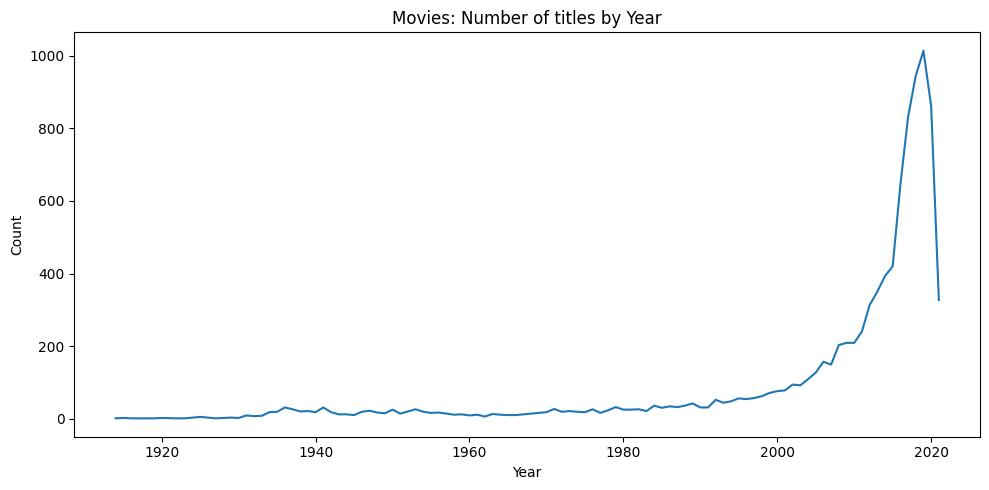

In [13]:
# 1) Line chart: content by year
def line_counts_by_year(df: pd.DataFrame, year_col: str, title: str):
    s = pd.to_numeric(df[year_col], errors="coerce").dropna().astype(int)
    counts = s.value_counts().sort_index()
    plt.figure(figsize=(10, 5))
    plt.plot(counts.index, counts.values)
    plt.title(title)
    plt.xlabel(year_col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

line_counts_by_year(movies, MOVIES_YEAR_COL, f"Movies: Number of titles by {MOVIES_YEAR_COL}")

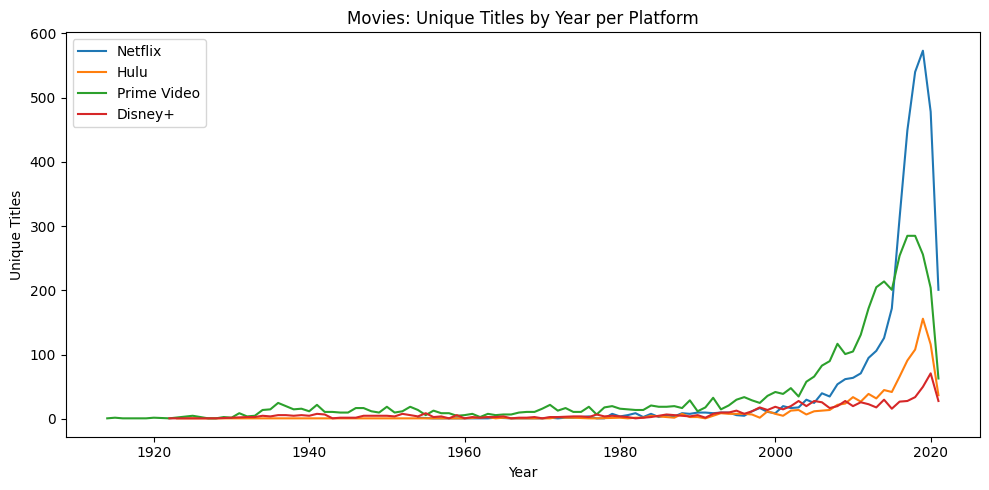

In [20]:
# 2) Line chart (multiple lines): content by year
def line_counts_by_year_multi(
    df: pd.DataFrame,
    year_col: str,
    platform_cols: list,
    title: str,
    count_col: str | None = None,
    min_year: int = 1900,
    max_year: int | None = None
):
    """
    Plot multiple lines by platform.

    Parameters
    ----------
    df : DataFrame
    year_col : str
    platform_cols : list of platform indicator columns (e.g. ['Netflix','Hulu',...])
    title : str
    count_col : str | None
        If None -> count rows
        If provided -> count unique values of this column
    """

    d = df.copy()

    # Clean year
    d[year_col] = pd.to_numeric(d[year_col], errors="coerce")
    d = d.dropna(subset=[year_col])
    d[year_col] = d[year_col].astype(int)

    if max_year is None:
        max_year = pd.Timestamp.now().year

    d = d[(d[year_col] >= min_year) & (d[year_col] <= max_year)]

    plt.figure(figsize=(10, 5))

    for platform in platform_cols:
        if platform not in d.columns:
            continue

        subset = d[d[platform] == 1]

        if count_col is None:
            counts = subset.groupby(year_col).size()
        else:
            counts = (
                subset
                .dropna(subset=[count_col])
                .groupby(year_col)[count_col]
                .nunique()
            )

        counts = counts.sort_index()

        plt.plot(counts.index, counts.values, label=platform)

    plt.title(title)
    plt.xlabel(year_col)
    plt.ylabel("Unique Titles" if count_col else "Count (rows)")
    plt.legend()
    plt.tight_layout()
    plt.show()

line_counts_by_year_multi(
    movies,
    year_col="Year",
    platform_cols=["Netflix", "Hulu", "Prime Video", "Disney+"],
    title="Movies: Unique Titles by Year per Platform",
    count_col="Title"   # important to avoid duplicates
)

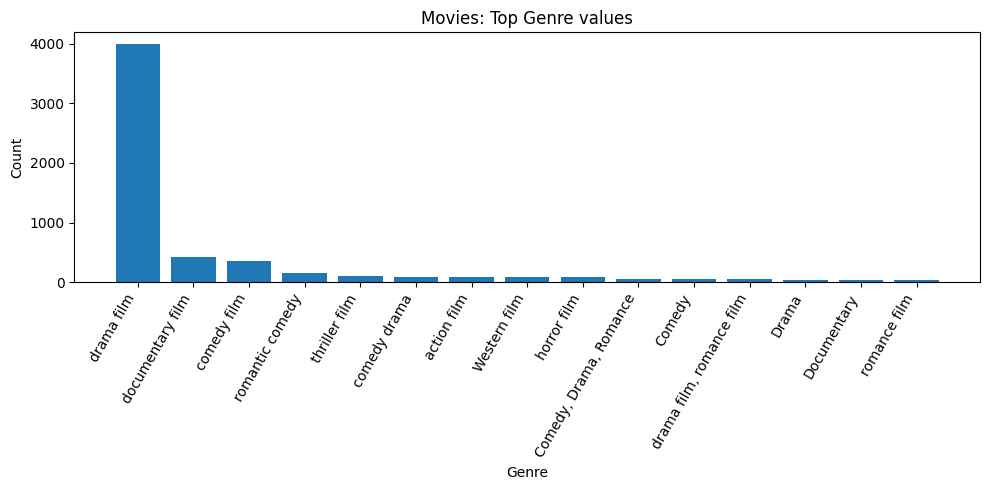

In [14]:
# 3) Bar chart: genre distribution (top 15)
def top_bar(series: pd.Series, title: str, xlabel: str = "", ylabel: str = "Count", top_n: int = 15, rotate: int = 45):
    vc = series.dropna().value_counts().head(top_n)
    plt.figure(figsize=(10, 5))
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotate, ha="right")
    plt.tight_layout()
    plt.show()

top_bar(movies[MOVIES_GENRE_COL], f"Movies: Top {MOVIES_GENRE_COL} values", xlabel=MOVIES_GENRE_COL, top_n=15, rotate=60)

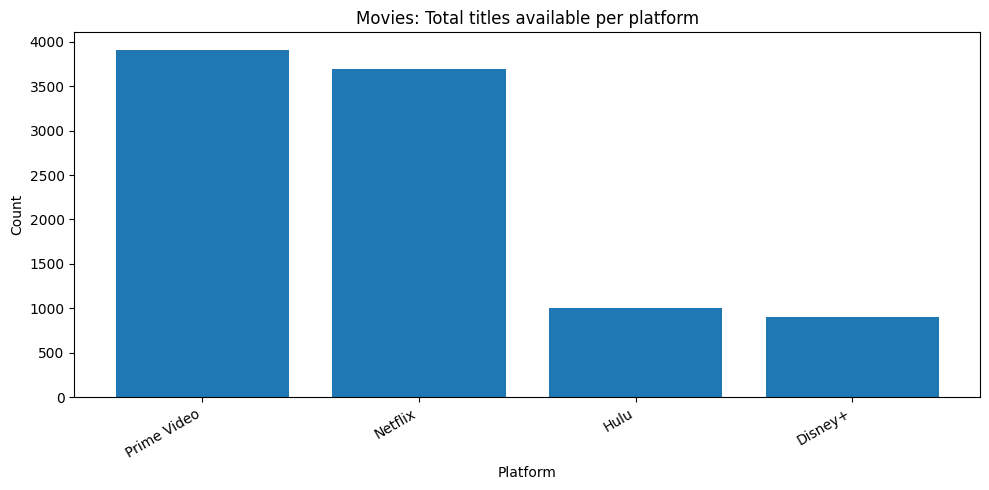

In [18]:
# 4) Bar chart: platform totals
# Create readable platform label
movies["Platform_Label"] = np.select(
    [
        movies["Netflix"] == 1,
        movies["Hulu"] == 1,
        movies["Prime Video"] == 1,
        movies["Disney+"] == 1
    ],
    ["Netflix", "Hulu", "Prime Video", "Disney+"],
    default="Other"
)
top_bar(movies["Platform_Label"], "Movies: Total titles available per platform", xlabel="Platform", rotate=30)

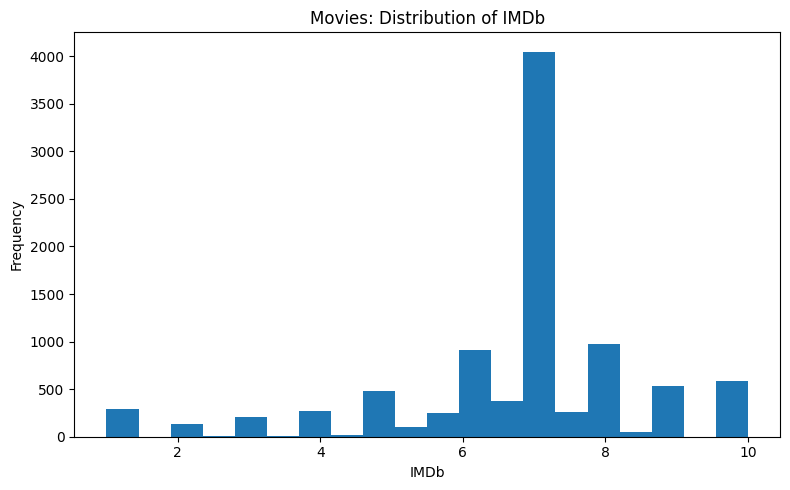

In [15]:
# 5) Histogram: ratings distribution
def hist(series: pd.Series, title: str, bins: int = 20, xlabel: str = "", ylabel: str = "Frequency"):
    s = pd.to_numeric(series, errors="coerce").dropna()
    plt.figure(figsize=(8, 5))
    plt.hist(s, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

hist(movies[MOVIES_RATING_COL], f"Movies: Distribution of {MOVIES_RATING_COL}", bins=20, xlabel=MOVIES_RATING_COL)

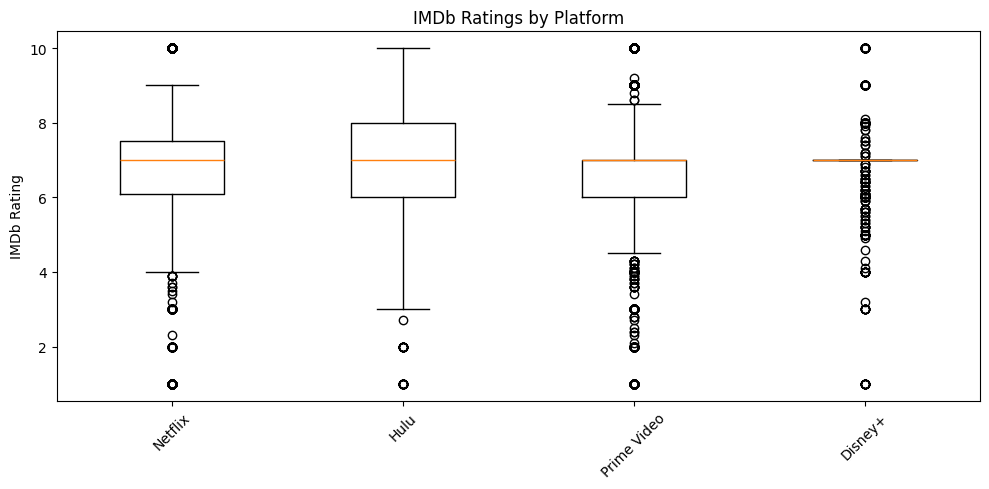

In [16]:
# 6) Box chart: ratings by platform
def box_plot(df: pd.DataFrame, column: str, by: str | None = None, 
             title: str = "", ylabel: str = "", rotate: int = 45):
    df_clean = df.copy()
    df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")

    if by is None:
        plt.figure(figsize=(6, 5))
        plt.boxplot(df_clean[column].dropna())
        plt.title(title if title else f"Boxplot of {column}")
        plt.ylabel(ylabel if ylabel else column)
    else:
        grouped_data = [
            df_clean[df_clean[by] == cat][column].dropna()
            for cat in df_clean[by].dropna().unique()
        ]

        categories = df_clean[by].dropna().unique()

        plt.figure(figsize=(10, 5))
        plt.boxplot(grouped_data)
        plt.xticks(range(1, len(categories) + 1), categories, rotation=rotate)
        plt.title(title if title else f"{column} by {by}")
        plt.ylabel(ylabel if ylabel else column)

    plt.tight_layout()
    plt.show()
    
box_plot(
    movies,
    column="IMDb",
    by="Platform_Label",
    title="IMDb Ratings by Platform",
    ylabel="IMDb Rating"
)

In [17]:
movies[movies["Disney+"]==1]["IMDb"].describe()

count    922.000000
mean       6.920824
std        1.347270
min        1.000000
25%        7.000000
50%        7.000000
75%        7.000000
max       10.000000
Name: IMDb, dtype: float64

## 6. Live coding demo — TV Shows (bar, histogram, line chart)

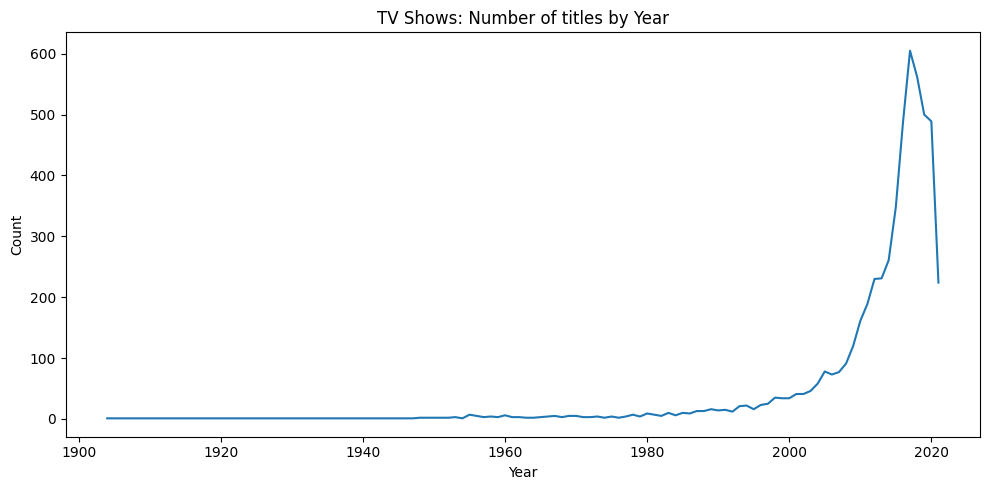

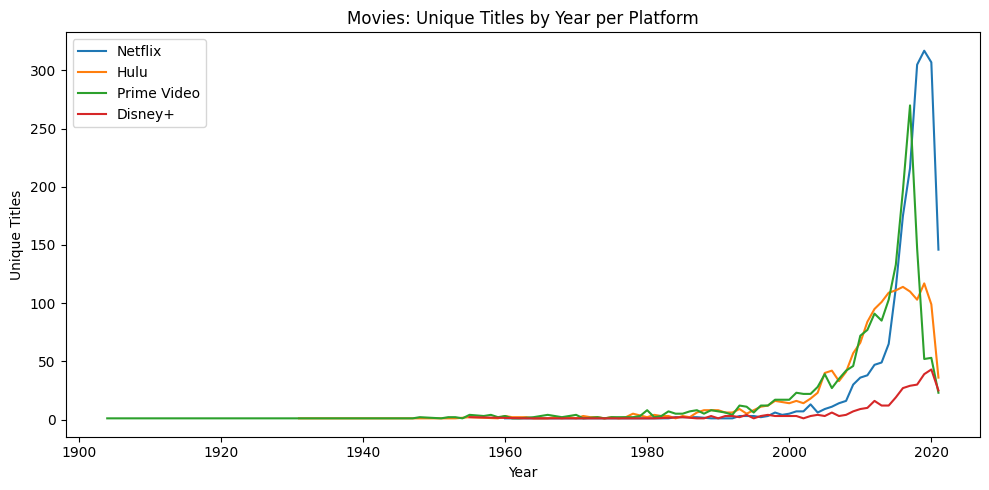

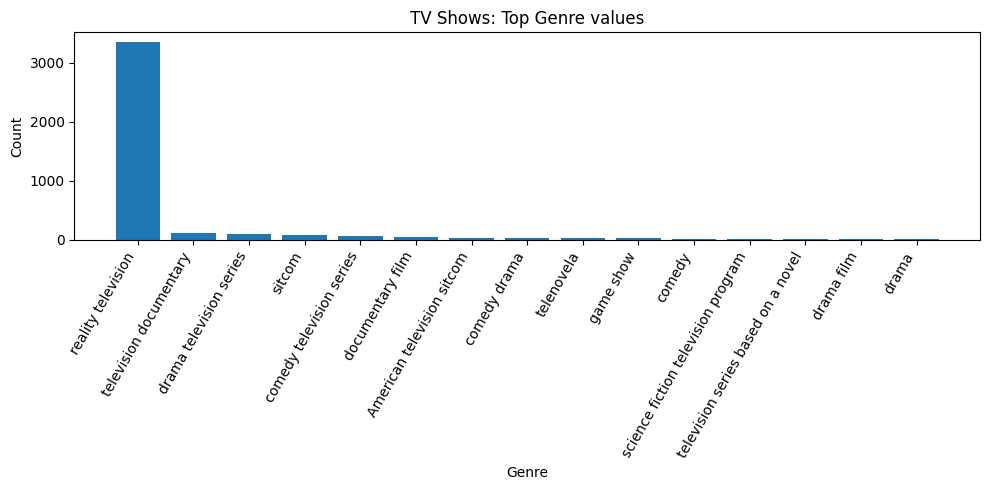

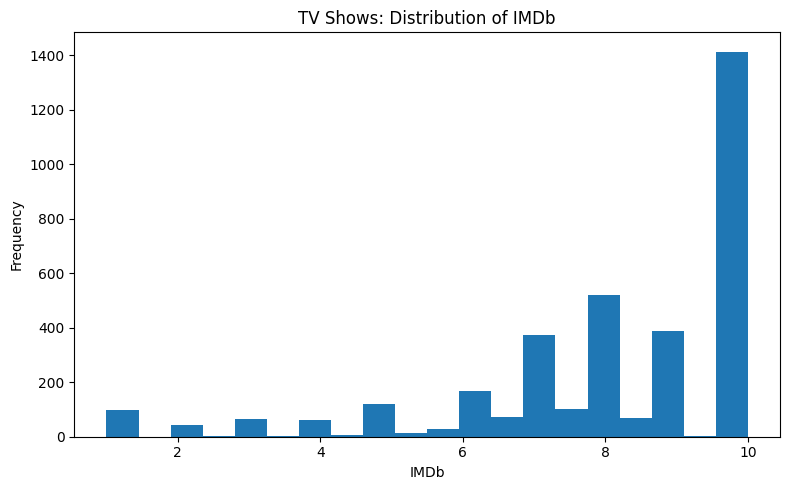

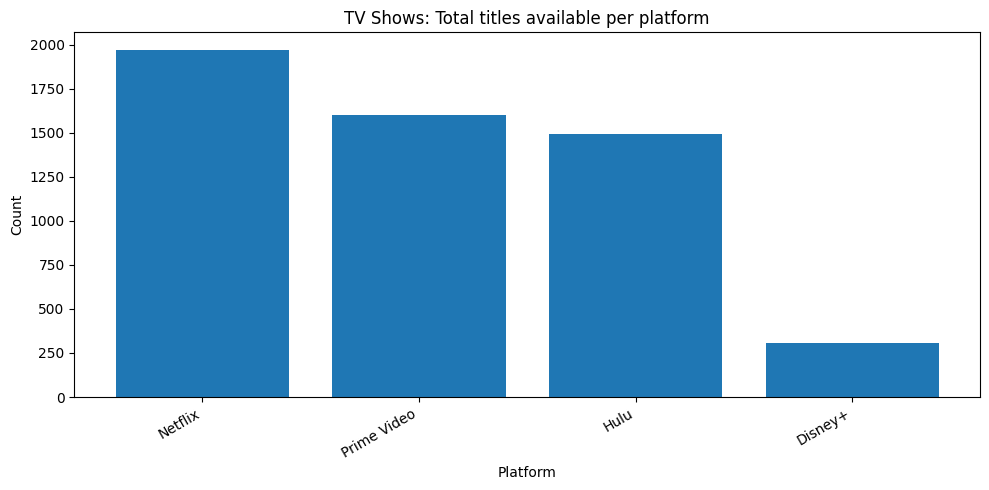

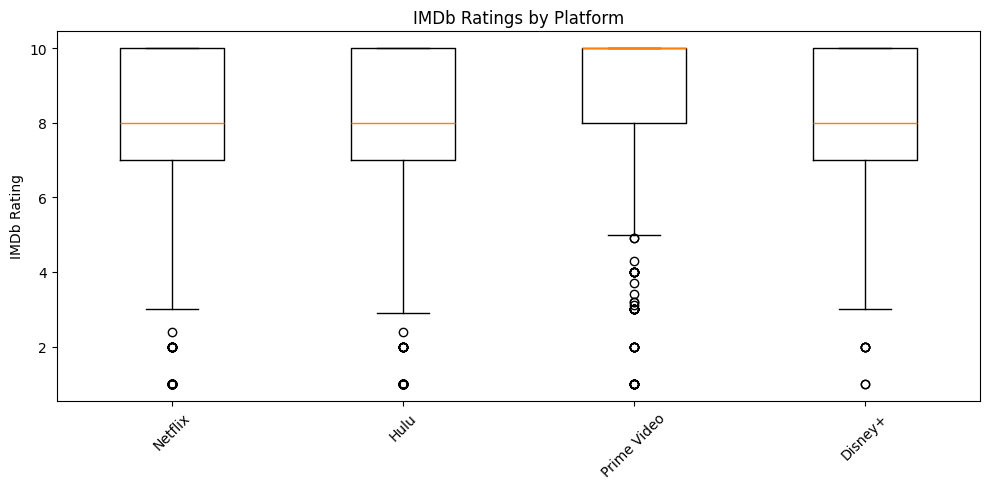

In [21]:
TV_YEAR_COL   = 'Year'
TV_GENRE_COL  = 'Genre'
TV_RATING_COL = 'IMDb'
TV_PLATFORM_COLS = ['Netflix', 'Hulu', 'Prime Video', 'Disney+']

# 1) Line chart: content by year
line_counts_by_year(tv, TV_YEAR_COL, f"TV Shows: Number of titles by {TV_YEAR_COL}")

# 2) Line chart (multiple lines): content by year
line_counts_by_year_multi(
    tv,
    year_col="Year",
    platform_cols=["Netflix", "Hulu", "Prime Video", "Disney+"],
    title="Movies: Unique Titles by Year per Platform",
    count_col="Title"   # important to avoid duplicates
)

# 3) Bar chart: genre distribution (top 15)
top_bar(tv[TV_GENRE_COL], f"TV Shows: Top {TV_GENRE_COL} values", xlabel=TV_GENRE_COL, top_n=15, rotate=60)

# 4) Histogram: ratings distribution
hist(tv[TV_RATING_COL], f"TV Shows: Distribution of {TV_RATING_COL}", bins=20, xlabel=TV_RATING_COL)

# 5) Bar chart: platform totals
# Create readable platform label
tv["Platform_Label"] = np.select(
    [
        tv["Netflix"] == 1,
        tv["Hulu"] == 1,
        tv["Prime Video"] == 1,
        tv["Disney+"] == 1
    ],
    ["Netflix", "Hulu", "Prime Video", "Disney+"],
    default="Other"
)
top_bar(tv["Platform_Label"], "TV Shows: Total titles available per platform", xlabel="Platform", rotate=30)

# 6) Box chart: ratings by platform
box_plot(
    tv,
    column="IMDb",
    by="Platform_Label",
    title="IMDb Ratings by Platform",
    ylabel="IMDb Rating"
)

## 7. In-session exercise (10 min) — Create 3 exploratory plots


### Instructions
1. Pick **Movies** or **TV Shows**
2. Create **3 different plots**
3. For each plot, write **1–2 sentences** interpreting the pattern

Suggested plot ideas:
- Content by year (line)
- Genre distribution (bar)
- Ratings histogram (hist)
- Top countries / languages (bar)
- Platform comparisons (bar) if indicator columns exist


In [ ]:
# Choose a dataset
df = movies  # change to tv if you prefer

# Explore columns to decide what to plot
df.columns

In [ ]:
# Plot 1 (bar chart) — edit the column name
# Example:
# top_bar(df["<column_name>"], "Plot 1 Title", xlabel="<column_name>", top_n=15, rotate=60)

In [ ]:
# Plot 2 (histogram) — edit the column name
# Example:
# hist(df["<numeric_column>"], "Plot 2 Title", bins=20, xlabel="<numeric_column>")

In [ ]:
# Plot 3 (line chart by year) — edit the column name
# Example:
# line_counts_by_year(df, "<year_column>", "Plot 3 Title")

## 8. Wrap-up (Q&A)


- What was the **most surprising trend** you found?
- Which plot best supports a **business story** about a platform's content strategy?
- What would you explore next if you had more time?
